In [101]:
#-----------  imports
import os
from pathlib import Path
import sys

# data
import numpy as np
import pandas as pd
import xarray as xr
import csv
import netCDF4 as nc

# plots
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import cmocean

# image processing
from skimage import feature, filters
import cv2

# ML
from skfda.ml.clustering import KMeans
from skfda.representation import FDataGrid
from scipy.stats import gaussian_kde
    
import re
import gc
import pywt
import mat73

from mpl_toolkits.axes_grid1 import make_axes_locatable

In [21]:
path_2018 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2018_38kHz_bspline_fpca.nc"
path_2021 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021_38kHz_bspline_fpca.nc"
path_20211 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021_transect_38kHz_bspline_fpca.nc"
path_2022 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2022_38kHz_bspline_fpca.nc"
path_2023 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2023_38kHz_bspline_fpca.nc"
path_2026 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2026_38kHz_bspline_fpca.nc"
path_temp_2018 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2018-01-09-2018-02-01_cropped.nc"
path_temp_2021 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2021-01-13-2021-03-04_cropped.nc"
path_temp_2022 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2022-02-03-2022-03-03_cropped.nc"
path_temp_2023 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2023-01-27-2023-02-26.nc_cropped.nc"
path_temp_2026 = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/raw/temp_sal/cmems_mod_glo_phy_my_0.083deg_P1D-m_thetao-so_50.00E-80.00E_60.00S-40.00S_0.49-5727.92m_2026-01-14-2026-02-25_cropped.nc"
path_fod = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/temp_sal/concat_raw_bspline_fpca.nc"
path_concat = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/fod/concat_raw_bspline.nc"
path_out = "/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute"
path_bathy = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/env/GLO-MFC_001_030_mask_bathy.nc"
path_fod_gmm = "/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/temp_sal/concat_raw_bspline_fpca_gmm.nc"

In [ ]:
PATHS = {
    2018: path_2018,
    2021: path_2021,
    20211 : path_20211,
    2022: path_2022,
    2023: path_2023,
    2026: path_2026,
}

PATHS_TEMP = {
    2018: path_temp_2018,
    2021: path_temp_2021,
    20211 : path_temp_2021,
    2022: path_temp_2022,
    2023: path_temp_2023,
    2026: path_temp_2026,
}

# ── Sélection mission ─────────────────────────────────────────────────────────
MISSION = 20211

path_in   = PATHS[MISSION]
path_temp = PATHS_TEMP[MISSION]
freq=38


/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021_transect_38kHz_bspline_fpca.nc


In [3]:
with xr.open_dataset(path_in) as ds : 
    print (ds.var)
    print(ds["day"])

NameError: name 'xr' is not defined

In [78]:
def create_path_figure(folder_comp, title, path_in=path_in, path_out=path_out) : 
    dataset_name = Path(path_in).stem
    save_dir = Path(path_out) / folder_comp
    save_dir.mkdir(parents=True, exist_ok=True)
    path = os.path.join(save_dir, f"{dataset_name}_{title}.png")
    return path

In [19]:
with xr.open_dataset(path_fod) as ds : 
    print(ds)
    print(ds["fpca_scores"].values.shape)
    

<xarray.Dataset> Size: 251MB
Dimensions:               (latitude: 241, longitude: 361, time: 178,
                           fpca_component_kept: 2, fpca_component: 18,
                           depth: 30, cluster: 3)
Coordinates:
  * latitude              (latitude) float32 964B -60.0 -59.92 ... -40.08 -40.0
  * longitude             (longitude) float32 1kB 50.0 50.08 ... 79.92 80.0
  * time                  (time) datetime64[ns] 1kB 2018-01-09 ... 2026-02-25
  * fpca_component_kept   (fpca_component_kept) int64 16B 0 1
  * fpca_component        (fpca_component) int64 144B 0 1 2 3 4 ... 14 15 16 17
  * depth                 (depth) float32 120B 0.494 1.541 2.646 ... 318.1 380.2
  * cluster               (cluster) int64 24B 0 1 2
Data variables:
    fpca_scores           (latitude, longitude, time, fpca_component_kept) float64 248MB ...
    fpca_eigenvalues      (fpca_component) float64 144B ...
    fpca_variance_ratio   (fpca_component) float64 144B ...
    fpca_cumvar           (fpc

# sanity checks

In [7]:
# verif b splines 

def plot_thetao_profiles(path_in, path_out, n=1000, time_idx=0, seed=42,
                         ncols=4, figsize_per_plot=(3.5, 4)):
    """
    Tire n profils aléatoires et sauvegarde les plots dans path_out.
    Tous les profils sont regroupés en pages de ncols*nrows subplots.

    ds         : xarray.Dataset ouvert
    path_out   : dossier de sortie (créé si absent)
    n          : nombre de profils à tirer
    time_idx   : indice temporel
    seed       : reproductibilité
    ncols      : colonnes par figure
    """
    ds = xr.open_dataset(path_in)
    Path(path_out).mkdir(parents=True, exist_ok=True)

    rng     = np.random.default_rng(seed)
    n_lat   = ds.dims["latitude"]
    n_lon   = ds.dims["longitude"]
    depth   = ds["depth"].values
    t_val   = ds["time"].isel(time=time_idx).values

    lat_idx = rng.integers(0, n_lat, n)
    lon_idx = rng.integers(0, n_lon, n)

    # Lecture en une fois pour éviter 1000 appels I/O
    print("Lecture des données…")
    raw_all = ds["thetao"].isel(time=time_idx).values            # (lat, lon, depth)
    rec_all = ds["thetao_reconstructed"].isel(time=time_idx).values

    nrows       = 5
    plots_per_fig = ncols * nrows
    n_figs      = int(np.ceil(n / plots_per_fig))

    print(f"Génération de {n_figs} figures ({n} profils, {plots_per_fig}/fig)…")

    for fig_i in range(n_figs):
        start = fig_i * plots_per_fig
        end   = min(start + plots_per_fig, n)
        n_sub = end - start

        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(figsize_per_plot[0] * ncols,
                                          figsize_per_plot[1] * nrows),
                                 sharey=True)
        axes = axes.flatten()

        for k in range(n_sub):
            li  = lat_idx[start + k]
            lo  = lon_idx[start + k]
            raw = raw_all[li, lo, :]
            rec = rec_all[li, lo, :]
            lat = float(ds["latitude"].isel(latitude=li))
            lon = float(ds["longitude"].isel(longitude=lo))

            ax = axes[k]
            ax.plot(raw, depth, color="steelblue", lw=1.2, label="original")
            ax.plot(rec, depth, color="tomato",    lw=1.2, ls="--", label="B-spline")
            ax.invert_yaxis()
            ax.set_title(f"({lat:.1f}°, {lon:.1f}°)", fontsize=8)
            ax.set_xlabel("°C", fontsize=7)
            if k % ncols == 0:
                ax.set_ylabel("Depth (m)", fontsize=7)
            ax.legend(fontsize=6)
            ax.grid(alpha=0.3)

        for j in range(n_sub, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f"thetao original vs B-spline  |  t={t_val}  "
                     f"({start+1}–{end}/{n})", fontsize=10)
        fig.tight_layout()

        out = Path(path_out) / f"thetao_profiles_{fig_i+1:03d}.png"
        fig.savefig(out, dpi=120, bbox_inches="tight")
        plt.close(fig)
        print(f"  [{fig_i+1}/{n_figs}] → {out}")
    ds.close()
    print(f"\n✓ {n_figs} figures sauvegardées dans {path_out}")

In [8]:
plot_thetao_profiles("/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/temp_sal/concat_raw_bspline.nc", "/home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_oceano/bsplines")

/tmp/ipykernel_36614/1037015433.py:20: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_lat   = ds.dims["latitude"]
/tmp/ipykernel_36614/1037015433.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_lon   = ds.dims["longitude"]


Lecture des données…


KeyboardInterrupt: 

In [ ]:
def verif_data_bathy(path_fod=path_fod):
    ds_fod = xr.open_dataset(path_fod)
    lat_fod = ds_fod["latitude"].values
    lon_fod = ds_fod["longitude"].values
    scores = ds_fod["fpca_scores"].values
   
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.COASTLINE)

    sc = ax.pcolormesh(
        lon_fod, lat_fod,
        scores[:, :, 0, 0],  # temps 1, profondeur 0
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r"
    )
    plt.colorbar(sc, ax=ax, label="FPCA score")
    ax.set_title("FPCA score - temps 0, profondeur 0")
    plt.show()
    ds_fod.close()

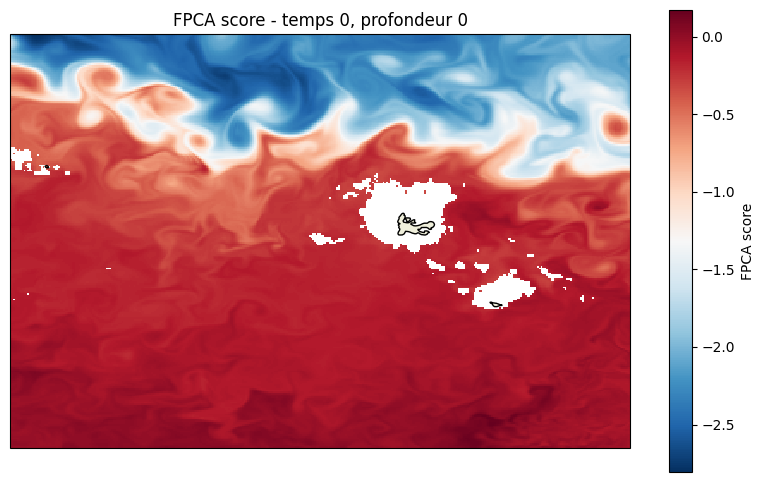

In [6]:
verif_data_bathy()

In [8]:
def verif_cropped_data(path_concat) : 
    ds = xr.open_dataset(path_concat)
    print(ds)
    # lat = ds["latitude"].values
    # lon = ds["longitude"].values
    # temp = ds["thetao_reconstructed"].values
    # print(temp.shape, lat.shape, lon.shape)
    # fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
    # ax.add_feature(cfeature.LAND)
    # ax.add_feature(cfeature.COASTLINE)
    # print("temp shape:", temp.shape)
    # print("lat shape:", lat.shape)
    # print("lon shape:", lon.shape)
    # sc = ax.pcolormesh(
    #     lon, lat,
    #     temp[0, :, :, 0],
    #     transform=ccrs.PlateCarree(),
    #     cmap="RdBu_r",
    #     shading="auto"  # évite le problème de dimensions
    # )
    
    # plt.colorbar(sc, ax=ax, label="FPCA score")
    # ax.set_title("FPCA score - temps 0, profondeur 0")
    # plt.show()
    ds.close()

In [9]:
verif_cropped_data("/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/temp_sal/concat_raw_bspline.nc")

<xarray.Dataset> Size: 10GB
Dimensions:                (time: 178, latitude: 241, longitude: 361,
                            depth: 30, bspline_k: 20, knot: 24)
Coordinates:
  * time                   (time) float64 1kB 1.515e+18 1.516e+18 ... 1.772e+18
  * latitude               (latitude) float64 2kB -60.0 -59.92 ... -40.08 -40.0
  * longitude              (longitude) float64 3kB 50.0 50.08 ... 79.92 80.0
  * depth                  (depth) float64 240B 0.494 1.541 ... 318.1 380.2
  * bspline_k              (bspline_k) int32 80B 0 1 2 3 4 5 ... 15 16 17 18 19
Dimensions without coordinates: knot
Data variables:
    thetao                 (time, latitude, longitude, depth) float32 2GB ...
    thetao_reconstructed   (time, latitude, longitude, depth) float32 2GB ...
    thetao_bspline_coeffs  (time, latitude, longitude, bspline_k) float32 1GB ...
    so                     (time, latitude, longitude, depth) float32 2GB ...
    so_reconstructed       (time, latitude, longitude, depth) f

# ANalysis clusters

In [12]:
with xr.open_dataset(path_fod) as ds : 
    print(ds)

<xarray.Dataset> Size: 253MB
Dimensions:               (latitude: 241, longitude: 361, time: 178,
                           fpca_component_kept: 2, fpca_component: 18,
                           depth: 30, cluster: 6)
Coordinates:
  * latitude              (latitude) float64 2kB -60.0 -59.92 ... -40.08 -40.0
  * longitude             (longitude) float64 3kB 50.0 50.08 ... 79.92 80.0
  * time                  (time) float64 1kB 1.515e+18 1.516e+18 ... 1.772e+18
  * fpca_component_kept   (fpca_component_kept) int64 16B 0 1
  * fpca_component        (fpca_component) int64 144B 0 1 2 3 4 ... 14 15 16 17
  * depth                 (depth) float64 240B 0.494 1.541 2.646 ... 318.1 380.2
  * cluster               (cluster) int64 48B 0 1 2 3 4 5
Data variables:
    fpca_scores           (latitude, longitude, time, fpca_component_kept) float64 248MB ...
    fpca_eigenvalues      (fpca_component) float64 144B ...
    fpca_variance_ratio   (fpca_component) float64 144B ...
    fpca_cumvar         

In [38]:
with xr.open_dataset("/home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2022_38kHz_bspline_fpca.nc") as ds : 
    print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:              (time: 876, depth: 98, bspline_k: 50, knot: 54,
                          fpca_component: 50)
Coordinates:
  * time                 (time) datetime64[ns] 7kB 2022-02-13T11:19:19.382399...
  * depth                (depth) float64 784B 25.0 35.0 45.0 ... 985.0 995.0
  * bspline_k            (bspline_k) int32 200B 0 1 2 3 4 5 ... 45 46 47 48 49
  * knot                 (knot) int32 216B 0 1 2 3 4 5 6 ... 48 49 50 51 52 53
  * fpca_component       (fpca_component) int32 200B 0 1 2 3 4 ... 46 47 48 49
Data variables: (12/16)
    Sv                   (time, depth) float32 343kB ...
    Sv_reconstructed     (time, depth) float64 687kB ...
    bspline_coeffs       (time, bspline_k) float64 350kB ...
    bspline_knots        (knot) float64 432B ...
    day                  (time) int8 876B ...
    latitude             (time) float64 7kB ...
    ...                   ...
    fpca_var_ratio       (fpca_component) float64 400B ...
    fpca_cumula

In [73]:
def attribute_cluster_fod_sv(path_in=path_in, path_fod=path_fod):

    # --- Load FOD dataset ---
    ds_fod = xr.open_dataset(path_fod)
    clusters  = ds_fod["gmm_cluster"].values
    proba     = ds_fod["gmm_proba"].values
    lat_fod   = ds_fod["latitude"].values
    lon_fod   = ds_fod["longitude"].values
    ds_fod.close()

    # --- Load Sv dataset entièrement en mémoire ---
    with xr.open_dataset(path_in) as ds:
        ds = ds.load()

    lat_sv = ds["latitude"].values
    lon_sv = ds["longitude"].values

    # --- Nearest neighbour sur grille FOD ---
    lat_idx = np.argmin(np.abs(lat_fod[:, None] - lat_sv[None, :]), axis=0)
    lon_idx = np.argmin(np.abs(lon_fod[:, None] - lon_sv[None, :]), axis=0)

    cluster_sv = clusters[lat_idx, lon_idx]
    proba_sv   = proba[lat_idx, lon_idx, :]

    # --- Ajouter les variables ---
    n_clusters = proba.shape[-1]

    ds = ds.assign(
        gmm_cluster=xr.DataArray(
            cluster_sv.astype(np.float32),
            dims=["time"],
            attrs={"long_name": "GMM cluster index (from FOD)"},
        ),
        gmm_proba=xr.DataArray(
            proba_sv.astype(np.float32),
            dims=["time", "cluster"],
            coords={"cluster": np.arange(n_clusters)},
            attrs={"long_name": "GMM cluster probability (from FOD)"},
        ),
    )

    # --- Construire le path de sortie : retire .nc, ajoute _gmm.nc ---
    path_out = path_in.replace(".nc", "_gmm.nc")
    ds.to_netcdf(path_out)
    print(f"Saved → {path_out}")
    return path_out

In [74]:
path_gmm = attribute_cluster_fod_sv(path_in)

Saved → /home/mmolinet/Elisou/MIO_internship_partII/data_01/processed/Echointegration2021_transect_38kHz_bspline_fpca_gmm.nc


In [75]:
def map_clusters_sv(path_gmm, save=False):
    with xr.open_dataset(path_gmm) as ds:
        cluster = ds["gmm_cluster"].values  # (time,)
        lat     = ds["latitude"].values
        lon     = ds["longitude"].values

    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.COASTLINE)

    sc = ax.scatter(lon, lat, c=cluster, transform=ccrs.PlateCarree(),
                    cmap="tab10", s=5)
    plt.colorbar(sc, ax=ax, label="Cluster GMM")
    ax.set_title("Clusters GMM le long de la trajectoire")
    if save : 
        path = create_path_figure(
            f"fpca_cluster/map_transect_cluster",
            f"map_transect_cluster",
            path_in=path_in,
        )
        print(f"    {path}")
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else : 
        plt.show()

In [79]:
map_clusters_sv(path_gmm, save=True)

    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca_cluster/map_transect_cluster/Echointegration2021_transect_38kHz_bspline_fpca_map_transect_cluster.png


# profil moyen et IQ par cluster

In [111]:
def plot_cp_cluster_sv(path_in=path_in, path_out=path_out, save=False):
    ds = xr.open_dataset(path_in)
    scores         = ds["fpca_scores"].values
    eigenfunctions = ds["fpca_eigenfunctions"].values
    depth          = ds["depth"].values
    labels         = ds["gmm_cluster"].values
    input_name     = os.path.splitext(os.path.basename(path_in))[0]
    ds.close()

    # --- nettoyer les NaN ---
    valid  = ~np.isnan(labels)
    labels = labels[valid].astype(int)
    scores = scores[valid]

    n_total      = len(labels)
    all_profiles = scores @ eigenfunctions.T

    k    = len(np.unique(labels))
    cmap = plt.get_cmap("tab10", k)

    fig, axes = plt.subplots(1, k, figsize=(3*k, 8), sharey=True)
    if k == 1:
        axes = [axes]

    for cluster in range(k):
        ax    = axes[cluster]
        mask  = labels == cluster
        n     = np.sum(mask)
        pct   = 100 * n / n_total          # ← pourcentage

        if n == 0:
            ax.set_title(f"Cluster {cluster+1}\n(vide)", fontsize=10, fontweight="bold")
            ax.set_visible(False)
            continue

        cluster_profiles = all_profiles[mask]
        median_profile   = np.median(cluster_profiles, axis=0)
        q1 = np.percentile(cluster_profiles, 25, axis=0)
        q3 = np.percentile(cluster_profiles, 75, axis=0)
        color = cmap(cluster)

        ax.plot(median_profile, depth, color=color, linewidth=2.5,
                label=f"Median", zorder=3)
        ax.plot(q1, depth, color=color, linestyle="--", linewidth=1.2,
                alpha=0.8, label="Q1", zorder=2)
        ax.plot(q3, depth, color=color, linestyle=":", linewidth=1.2,
                alpha=0.8, label="Q3", zorder=2)
        ax.fill_betweenx(depth, q1, q3, color=color, alpha=0.12, label="IQR")

        ax.set_title(f"Cluster {cluster+1}\nn={n} ({pct:.1f}%)",   # ← ici
                     fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.2)
        ax.spines[["top", "right"]].set_visible(False)
        if cluster == 0:
            ax.set_ylabel("Depth (m)", fontsize=9)
        
        ax.set_xlabel("Sv (dB)", fontsize=9)
    ax.invert_yaxis()
    axes[-1].legend(fontsize=7, loc="lower right", frameon=True)
    fig.suptitle("Cluster median profile and interquartile range", y=0.98)
    fig.text(0.5, 0.93, input_name, ha="center", fontsize=9)
    fig.subplots_adjust(wspace=0.35)

    if save:
        path = create_path_figure(
            f"fpca_cluster/mean_profile_cluster",
            f"mean_profile_cluster",
            path_in=path_in,
        )
        print(f"    {path}")
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [112]:
plot_cp_cluster_sv(path_gmm, save=True)

    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca_cluster/mean_profile_cluster/Echointegration2021_transect_38kHz_bspline_fpca_gmm_mean_profile_cluster.png


# Scores par PC par cluster

In [104]:
def plot_scores_by_cluster(path_in=path_in, n_cols=3, save=False):
    ds = xr.open_dataset(path_in)
    scores = ds["fpca_scores"].values
    labels = ds["gmm_cluster"].values
    cumvar = ds["fpca_cumulative_var"].values
    ds.close()

    # --- composantes à 90% de variance ---
    n_comp = int(np.searchsorted(cumvar, 0.90)) + 1

    # --- nettoyer les NaN ---
    valid  = ~np.isnan(labels)
    scores = scores[valid, :n_comp]
    labels = labels[valid].astype(int)

    k    = len(np.unique(labels))
    cmap = plt.get_cmap("tab10", k)

    # --- compter les individus par cluster ---
    cluster_counts = [np.sum(labels == c) for c in range(k)]

    n_rows = int(np.ceil(n_comp / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5*n_cols, 4*n_rows),
                             sharey=False)
    axes = np.array(axes).flatten()

    for i in range(n_comp):
        ax               = axes[i]
        data_per_cluster = [scores[labels == c, i] for c in range(k)]
        colors           = [cmap(c) for c in range(k)]

        bp = ax.boxplot(
            data_per_cluster,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            flierprops=dict(marker=".", markersize=2, alpha=0.3),
        )
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        var_i = (cumvar[i] - cumvar[i-1]) if i > 0 else cumvar[0]
        ax.set_title(f"PC {i+1}  ({var_i*100:.1f}% var / {cumvar[i]*100:.1f}% cum)",
                     fontsize=9, fontweight="bold")
        ax.set_xticks(range(1, k+1))
        ax.set_xticklabels([f"C{c+1}" for c in range(k)], fontsize=8)
        ax.set_ylabel("Score FPCA", fontsize=8)
        ax.grid(True, axis="y", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)

    # --- cacher les axes vides ---
    for j in range(n_comp, len(axes)):
        axes[j].set_visible(False)

    # --- légende commune : couleur + n par cluster ---
    legend_handles = [
        mpatches.Patch(facecolor=cmap(c), alpha=0.7,
                       label=f"Cluster {c+1}  (n={cluster_counts[c]})")
        for c in range(k)
    ]
    fig.legend(handles=legend_handles,
               loc="lower center",
               ncol=k,
               fontsize=9,
               frameon=True,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle(f"Scores FPCA par cluster — {n_comp} PC à 90% de variance",
                 fontsize=13, y=1.01)
    plt.tight_layout()

    if save:
        path = create_path_figure(
            f"fpca_cluster/scores_by_cluster",
            f"scores_by_cluster",
            path_in=path_in,
        )
        print(f"    {path}")
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [110]:
plot_scores_by_cluster(path_gmm, n_cols=4, save=True)

    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca_cluster/scores_by_cluster/Echointegration2021_transect_38kHz_bspline_fpca_gmm_scores_by_cluster.png


In [102]:
def plot_scores_by_cluster_daynight(path_in=path_in, n_cols=3, save=False):
    ds = xr.open_dataset(path_in)
    scores = ds["fpca_scores"].values
    labels = ds["gmm_cluster"].values
    cumvar = ds["fpca_cumulative_var"].values
    day    = ds["day"].values                 
    ds.close()

    # --- composantes à 90% de variance ---
    n_comp = int(np.searchsorted(cumvar, 0.90)) + 1

    # --- nettoyer les NaN ---
    valid  = ~np.isnan(labels)
    scores = scores[valid, :n_comp]
    labels = labels[valid].astype(int)
    day    = day[valid]

    k    = len(np.unique(labels))
    cmap = plt.get_cmap("tab10", k)

    day_masks = {"Jour": day == 3, "Nuit": day == 1}
    n_rows    = int(np.ceil(n_comp / n_cols))

    for period, dmask in day_masks.items():
        s_period = scores[dmask]
        l_period = labels[dmask]

        # --- compter les individus par cluster pour la légende ---
        cluster_counts = [np.sum(l_period == c) for c in range(k)]

        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(5*n_cols, 4*n_rows),
                                 sharey=False)
        axes = np.array(axes).flatten()

        for i in range(n_comp):
            ax               = axes[i]
            data_per_cluster = [s_period[l_period == c, i] for c in range(k)]
            colors           = [cmap(c) for c in range(k)]

            bp = ax.boxplot(
                data_per_cluster,
                patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3),
            )
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            var_i = (cumvar[i] - cumvar[i-1]) if i > 0 else cumvar[0]
            ax.set_title(f"PC {i+1}  ({var_i*100:.1f}% var / {cumvar[i]*100:.1f}% cum)",
                         fontsize=9, fontweight="bold")
            ax.set_xticks(range(1, k+1))
            ax.set_xticklabels([f"C{c+1}" for c in range(k)], fontsize=8)
            ax.set_ylabel("Score FPCA", fontsize=8)
            ax.grid(True, axis="y", alpha=0.3)
            ax.spines[["top", "right"]].set_visible(False)

        for j in range(n_comp, len(axes)):
            axes[j].set_visible(False)

        # --- légende commune : couleur + n par cluster ---
        legend_handles = [
            mpatches.Patch(facecolor=cmap(c), alpha=0.7,
                           label=f"Cluster {c+1}  (n={cluster_counts[c]})")
            for c in range(k)
        ]
        fig.legend(handles=legend_handles,
                   loc="lower center",
                   ncol=k,
                   fontsize=9,
                   frameon=True,
                   bbox_to_anchor=(0.5, -0.02))

        n_period = np.sum(dmask)
        fig.suptitle(
            f"Scores FPCA par cluster — {period} (n={n_period}) — {n_comp} PC à 90% variance",
            fontsize=13, y=1.01
        )
        plt.tight_layout()

        if save:
            path = create_path_figure(
                f"fpca_cluster/scores_by_cluster_day_night",
                f"scores_by_cluster_{period}",
                path_in=path_in,
            )
            print(f"    {path}")
            plt.savefig(path, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

In [109]:
plot_scores_by_cluster_daynight(path_gmm, save=True, n_cols=4)

    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca_cluster/scores_by_cluster_day_night/Echointegration2021_transect_38kHz_bspline_fpca_gmm_scores_by_cluster_Jour.png
    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca_cluster/scores_by_cluster_day_night/Echointegration2021_transect_38kHz_bspline_fpca_gmm_scores_by_cluster_Nuit.png


In [120]:
def plot_ts_profiles_by_cluster(year, path_fod=path_fod, n_cols=3, save=False):
    ds = xr.open_dataset(path_fod)

    scores         = ds["fpca_scores"].values            # (lat, lon, time, fpca_component_kept)
    ef_thetao      = ds["eigenfunction_thetao"].values   # (fpca_component, depth)
    ef_so          = ds["eigenfunction_so"].values       # (fpca_component, depth)
    mean_thetao    = ds["mean_profile_thetao"].values    # (depth,)
    mean_so        = ds["mean_profile_so"].values        # (depth,)
    depth          = ds["depth"].values                  # (depth,)
    labels         = ds["gmm_cluster"].values            # (lat, lon)
    time           = ds["time"].values                   # (time,) en nanosecondes
    ds.close()

    # --- filtrer sur l'année 2021 ---
    time_dt = pd.to_datetime(time)
    print(time_dt.year[:5])
    mask_2021 = time_dt.year == year
    scores_2021 = scores[:, :, mask_2021, :]             # (lat, lon, time_2021, 2)

    # --- reconstruction des profils T et S ---
    # scores_2021 @ ef[:2, :] → on garde seulement les fpca_component_kept
    # shape : (lat, lon, time_2021, depth)
    ef_t = ef_thetao[:scores_2021.shape[-1], :]          # (2, depth)
    ef_s = ef_so[:scores_2021.shape[-1], :]              # (2, depth)

    profiles_t = scores_2021 @ ef_t + mean_thetao        # (lat, lon, time_2021, depth)
    profiles_s = scores_2021 @ ef_s + mean_so            # (lat, lon, time_2021, depth)

    # --- aplatir lat/lon pour grouper par cluster ---
    nlat, nlon, ntime, ndepth = profiles_t.shape
    profiles_t_flat = profiles_t.reshape(-1, ntime, ndepth)   # (lat*lon, time_2021, depth)
    profiles_s_flat = profiles_s.reshape(-1, ntime, ndepth)
    labels_flat     = labels.reshape(-1)                       # (lat*lon,)

    # moyenne temporelle par pixel → (lat*lon, depth)
    mean_t = np.nanmean(profiles_t_flat, axis=1)
    mean_s = np.nanmean(profiles_s_flat, axis=1)

    # --- masque NaN ---
    valid   = ~np.isnan(labels_flat)
    mean_t  = mean_t[valid]
    mean_s  = mean_s[valid]
    labels_flat = labels_flat[valid].astype(int)

    k         = len(np.unique(labels_flat))
    n_total   = len(labels_flat)
    cmap      = plt.get_cmap("tab10", k)

    for var_name, profiles, unit in [("Température", mean_t, "°C"),
                                      ("Salinité",     mean_s, "psu")]:

        fig, axes = plt.subplots(1, k, figsize=(3*k, 8), sharey=True)
        if k == 1:
            axes = [axes]

        for c in range(k):
            ax   = axes[c]
            mask = labels_flat == c
            n    = np.sum(mask)
            pct  = 100 * n / n_total
            color = cmap(c)

            data = profiles[mask]                          # (n_cluster, depth)
            median = np.median(data, axis=0)
            q1     = np.percentile(data, 25, axis=0)
            q3     = np.percentile(data, 75, axis=0)

            ax.plot(median, depth, color=color, linewidth=2.5, label="Médiane", zorder=3)
            ax.plot(q1, depth, color=color, linestyle="--", linewidth=1.2,
                    alpha=0.8, label="Q1", zorder=2)
            ax.plot(q3, depth, color=color, linestyle=":", linewidth=1.2,
                    alpha=0.8, label="Q3", zorder=2)
            ax.fill_betweenx(depth, q1, q3, color=color, alpha=0.12, label="IQR")

            ax.set_title(f"Cluster {c+1}\nn={n} ({pct:.1f}%)", fontsize=10, fontweight="bold")
            ax.grid(True, alpha=0.2)
            ax.spines[["top", "right"]].set_visible(False)
            if c == 0:
                ax.set_ylabel("Profondeur (m)", fontsize=9)
            
            ax.set_xlabel(f"{var_name} ({unit})", fontsize=9)
        ax.invert_yaxis()
        axes[-1].legend(fontsize=7, loc="lower right", frameon=True)
        fig.suptitle(f"Profils {var_name} par cluster — moyenne 2021", y=0.98, fontsize=12)
        fig.subplots_adjust(wspace=0.35)
        plt.tight_layout()
        if save:
            path = create_path_figure(
                f"env_clusters/temp_sal_distrib_by_cluster",
                f"{year}_{var_name}_distrib_by_cluster",
                path_in=path_in,
            )
            print(f"    {path}")
            plt.savefig(path, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

In [121]:
plot_ts_profiles_by_cluster(2021, save=True)

Index([2018, 2018, 2018, 2018, 2018], dtype='int32')


/tmp/ipykernel_36614/1190657150.py:36: RuntimeWarning: Mean of empty slice
  mean_t = np.nanmean(profiles_t_flat, axis=1)
/tmp/ipykernel_36614/1190657150.py:37: RuntimeWarning: Mean of empty slice
  mean_s = np.nanmean(profiles_s_flat, axis=1)


    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/env_clusters/temp_sal_distrib_by_cluster/Echointegration2021_transect_38kHz_bspline_fpca_2021_Température_distrib_by_cluster.png
    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/env_clusters/temp_sal_distrib_by_cluster/Echointegration2021_transect_38kHz_bspline_fpca_2021_Salinité_distrib_by_cluster.png


In [126]:
def compute_nasc(path_in: str) -> np.ndarray:
    """
    Calcule le NASC (m² nmi⁻²) par ping.
    NASC = 4π × 1852² × sA      avec  sA = Σ_z  sv_lin(z) × dz
    Retourne nasc : (n_ping,)
    """
    ds     = xr.open_dataset(path_in)
    sv_raw = ds["Sv"].values      # (n_ping, n_depth)
    depths = ds["depth"].values   # (n_depth,)
    ds.close()

    dz     = float(np.median(np.diff(depths)))
    sv_lin = 10.0 ** (sv_raw / 10.0)             # (n_ping, n_depth)

    n_valid           = np.sum(np.isfinite(sv_lin), axis=1).astype(float)  # (n_ping,)
    n_valid[n_valid == 0] = np.nan

    sa   = np.nansum(sv_lin, axis=1) * dz        # (n_ping,)
    nasc = 4 * np.pi * 1852**2 * sa              # (n_ping,)
    nasc[n_valid == 0] = np.nan

    return nasc                                   # (n_ping,)

In [142]:
def plot_nasc_by_cluster(path_in=path_in, save=False):
    # --- NASC ---
    nasc   = compute_nasc(path_in)
    ds     = xr.open_dataset(path_in)
    labels = ds["gmm_cluster"].values
    ds.close()

    # --- Nettoyer ---
    valid  = ~np.isnan(labels) & np.isfinite(nasc)
    nasc   = nasc[valid]
    labels = labels[valid].astype(int)

    k       = len(np.unique(labels))
    n_total = len(labels)
    cmap    = plt.get_cmap("tab10", k)
    input_name = os.path.splitext(os.path.basename(path_in))[0]
    # --- Filtrer clusters vides ---
    clusters_valides = [c for c in range(k) if np.sum(labels == c) > 0]
    data_per_cluster = [nasc[labels == c] for c in clusters_valides]
    colors           = [cmap(c) for c in clusters_valides]
    xtick_labels     = [f"C{c+1}\n(n={np.sum(labels==c)}, {100*np.sum(labels==c)/n_total:.1f}%)"
                        for c in clusters_valides]
    k_val = len(clusters_valides)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ── Boxplot ──────────────────────────────────────────────────────────────
    ax = axes[0]
    bp = ax.boxplot(
        data_per_cluster,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
        showfliers=False,
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, k_val+1))
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_ylabel("NASC (m² nmi⁻²)", fontsize=10)
    ax.set_title("Distribution du NASC par cluster", fontsize=11, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    # ── Barplot médiane ± IQR ─────────────────────────────────────────────
    ax2  = axes[1]
    medians = [np.median(d) for d in data_per_cluster]
    q1s     = [np.percentile(d, 25) for d in data_per_cluster]
    q3s     = [np.percentile(d, 75) for d in data_per_cluster]
    x       = np.arange(k_val)

    ax2.bar(x, medians, color=colors, alpha=0.7, edgecolor="black", linewidth=0.8)
    ax2.errorbar(
        x, medians,
        yerr=[np.array(medians) - np.array(q1s),
              np.array(q3s)     - np.array(medians)],
        fmt="none", color="black", capsize=5, linewidth=1.5
    )
    ax2.set_xticks(x)
    ax2.set_xticklabels(xtick_labels, fontsize=8)
    ax2.set_ylabel("NASC médian (m² nmi⁻²)", fontsize=10)
    ax2.set_title("NASC médian ± IQR par cluster", fontsize=11, fontweight="bold")
    ax2.grid(True, axis="y", alpha=0.3)
    ax2.spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"Analyse du NASC par cluster GMM — 38 kHz\n{input_name}", fontsize=13, y=1.01)
    plt.tight_layout()

    if save:
        path = create_path_figure(
            "fpca_cluster/nasc_by_cluster",
            "nasc_by_cluster",
            path_in=path_in,
        )
        print(f"    {path}")
        plt.savefig(path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [143]:
plot_nasc_by_cluster(path_gmm, save=True)

    /home/mmolinet/Elisou/MIO_internship_partII/outputs_01/exploration_data_brute/fpca_cluster/nasc_by_cluster/Echointegration2021_transect_38kHz_bspline_fpca_gmm_nasc_by_cluster.png


In [129]:
ds = xr.open_dataset(path_gmm)
print(ds["Sv"].shape)
print(ds["gmm_cluster"].shape)
ds.close()

(42820, 491)
(42820,)
